# **Model Training Phase 2 (with `XGBClassifier`, `LGBMClassifier` , and `CatBoostClassifier`)**

In [1]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np

In [2]:
import pickle
with open("/kaggle/input/datasets/ashura369/my-dataset/df_1.kl", "rb") as f:
    data = pickle.load(f)

In [3]:
data.sample(6)

,id,name,date,day_name,hour,timezone,airlines,feedback,reason,reason_confidence,retweets,sentiment
12278,570244934634090496,planedoc71,2015-02-24,Tuesday,7,London,American,thanks for finally letting me get through to b...,Customer Service Issue,0.3168,0,negative
1179,569904406285516800,Natemaniac12,2015-02-23,Monday,8,Pacific_Time,United,looks like today will be my 6th consecutive de...,Late Flight,1.0000,0,negative
6057,568391382496378880,Fuzzyrussianman,2015-02-19,Thursday,4,Central_Time,Southwest,I'm getting leathery from the heat on 4251 bef...,Bad Flight,1.0000,0,negative
7724,569305705750114305,MaliceDavericks,2015-02-21,Saturday,17,Eastern_Time,Delta,figured it out 4 flight 2morrow. Hard to belie...,Customer Service Issue,0.3684,0,negative
4810,569704587315138560,sahandmirza,2015-02-22,Sunday,19,Eastern_Time,Southwest,crew of WN3946 SAN-SFO was brilliant! Rita was...,Bad Flight,0.0000,0,positive
12973,569971216934526976,pantsasnapkins,2015-02-23,Monday,13,Eastern_Time,American,What's with your baggage handlers calling out ...,Customer Service Issue,0.3808,0,negative


## Removing the unrequired columns
- id
- name
- date

In [4]:
data = data.drop(columns=['id', 'name','date'])

## Doing Lemmatization

In [5]:
!pip install cleantext

In [6]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
stop_words =  stopwords.words('english')

from nltk.stem import WordNetLemmatizer
lmt = WordNetLemmatizer()

from cleantext import clean

import re
import emoji

In [7]:
def transform(txt):
    txt = clean(txt,lowercase=True,punct=True)    
    txt = re.sub(r'(.)\1{2,}', r'\1', txt)              
    txt = re.sub(r'https?://\S+|www\.\S+', '', txt)    
    txt = re.sub(r'@\S+', '', txt)                     
    txt = emoji.demojize(txt)                           
    txt = word_tokenize(txt)
                       
    temp = [lmt.lemmatize(word, pos='v') for word in txt if word not in stop_words and (word.isalpha() or (word.startswith(':') and word.endswith(':')))]
                        
    temp2 = temp[:]
    temp2 = " ".join(temp)
    return temp2


In [8]:
transform('Hello my name is Pradhan.')

'hello name pradhan'

### **Observation** : The above `transform()` function takes the raw string text, and processes them.
Working of the function :- <br>
1. Lowercasing and Remvoing Punctuations
2. Removing Elongated words
    - cooooool : cool
    - hiiiiiii : hi
3. Remvoing URLs
4. Removing social media handles
    - @biswajeet369
5. Converting emojis into texts
6. Word Tokenization
7. Removing stop wrods, and doing lemmatization

## Putting all the text based features into one feature

In [9]:
data['text'] = data[['day_name','timezone','airlines','feedback','reason']].astype(str).agg(" ".join, axis=1)

In [10]:
data = data[['hour','reason_confidence','retweets','text','sentiment']]

In [11]:
data.head(6)

,hour,reason_confidence,retweets,text,sentiment
0,11,0.0000,0,Tuesday Eastern_Time Virgin_America What said....,neutral
1,11,0.0000,0,Tuesday Pacific_Time Virgin_America plus you'v...,positive
2,11,0.0000,0,Tuesday Central_Time Virgin_America I didn't t...,neutral
3,11,0.7033,0,Tuesday Pacific_Time Virgin_America it's reall...,negative
4,11,1.0000,0,Tuesday Pacific_Time Virgin_America and it's a...,negative
5,11,0.6842,0,Tuesday Pacific_Time Virgin_America seriously ...,negative


In [12]:
x = data.drop(columns=['sentiment'])
y = data['sentiment']

#### Using `LabelEncoder` on sentiment

In [13]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer

In [14]:
le = LabelEncoder()
y = le.fit_transform(y)

In [15]:
y

array([1, 2, 1, ..., 1, 0, 1], shape=(14640,))

### **Observation** : Using `LabelEncoder` on sentiment labels each of the classes into numbers
Labels : 
- negative - 0
- neutral - 1
- positive - 2

## Before doing Scaling on numerical data first, we have to apply the lemmatization on text based data

In [16]:
x['text_transformed'] = x['text'].apply(transform)

In [17]:
x.head(6)

,hour,reason_confidence,retweets,text,text_transformed
0,11,0.0000,0,Tuesday Eastern_Time Virgin_America What said....,tuesday easterntime virginamerica say flight b...
1,11,0.0000,0,Tuesday Pacific_Time Virgin_America plus you'v...,tuesday pacifictime virginamerica plus youve a...
2,11,0.0000,0,Tuesday Central_Time Virgin_America I didn't t...,tuesday centraltime virginamerica didnt today ...
3,11,0.7033,0,Tuesday Pacific_Time Virgin_America it's reall...,tuesday pacifictime virginamerica really aggre...
4,11,1.0000,0,Tuesday Pacific_Time Virgin_America and it's a...,tuesday pacifictime virginamerica really big b...
5,11,0.6842,0,Tuesday Pacific_Time Virgin_America seriously ...,tuesday pacifictime virginamerica seriously wo...


## Using `MinMaxScaler` on hour, and `StandardScaler` on reason_confidence, and retweets

In [18]:
processor = ColumnTransformer(
    transformers=[
        ('minmax', MinMaxScaler(), ['hour']),
        ('standard', StandardScaler(), ['reason_confidence','retweets']),
    ], remainder='drop'
)

In [19]:
temp = processor.fit_transform(x)

In [20]:
x[['hour','reason_confidence','retweets']] = pd.DataFrame(temp, columns=['hour','reason_confidence','retweets'])

In [21]:
x = x.drop(columns='text')
x.head(6)

,hour,reason_confidence,retweets,text_transformed
0,0.478261,-1.208684,-0.110828,tuesday easterntime virginamerica say flight b...
1,0.478261,-1.208684,-0.110828,tuesday pacifictime virginamerica plus youve a...
2,0.478261,-1.208684,-0.110828,tuesday centraltime virginamerica didnt today ...
3,0.478261,0.585982,-0.110828,tuesday pacifictime virginamerica really aggre...
4,0.478261,1.343095,-0.110828,tuesday pacifictime virginamerica really big b...
5,0.478261,0.537243,-0.110828,tuesday pacifictime virginamerica seriously wo...


In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=10, max_features=4000, sublinear_tf=True)

In [23]:
temp = tfidf.fit_transform(x['text_transformed'])

In [24]:
# print(temp))
temp.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(14640, 2882))

In [25]:
print(tfidf.get_feature_names_out().tolist())

['aa', 'aa customer', 'aadvantage', 'able', 'able get', 'absolute', 'absolutely', 'absurd', 'abudhabi', 'abudhabi usairways', 'accept', 'acceptable', 'access', 'accommodate', 'accord', 'account', 'acct', 'accurate', 'across', 'act', 'action', 'actual', 'actually', 'add', 'additional', 'address', 'admirals', 'admirals club', 'advance', 'advantage', 'advertise', 'advise', 'advisory', 'affect', 'afford', 'afternoon', 'age', 'agent', 'agents', 'ago', 'ah', 'ahead', 'air', 'air customer', 'aircraft', 'airfare', 'airline', 'airline cancel', 'airline cant', 'airline customer', 'airline ever', 'airline flight', 'airlines', 'airlines cant', 'airlines customer', 'airplane', 'airport', 'airport cant', 'airport customer', 'airport flight', 'airports', 'airways', 'alaska', 'alaska american', 'alaska delta', 'alaska southwest', 'alaska unite', 'alaska usairways', 'alert', 'alist', 'allow', 'almost', 'almost hour', 'almost hours', 'alone', 'along', 'already', 'already cancel', 'also', 'alternate', 'a

### **Observation** :
- Here we have used `ColumnTransformer` to transform columns into required columns
    1. Third `MinMaxScaler` was used on hour, as we know the minimum and maximum value of hour, which is btwn 0 to 23.
    2. Fourth we used `StandardScaler` on reason_confidence and retweets because the minimum and maximum number was not fixed for both of these, and hence both these features became mean centered.

- Here we have used `TfidfVectorizer` with `ngram_range` of (1,2). This is bcoz we have added all the single word classes (day_name, timezone, airlines, reason) and the text bases class (feedback) into one feature (text_transformed). 
- And we have added `min_df` as 10 bcoz we want to remove the words that appear less than 10 times in the entire corpus.
- Here `max_features` was set to 4000 because, 4000 words would be more than enough to find what words determine the sentiment of the given input.

In [26]:
x.columns

Index(['hour', 'reason_confidence', 'retweets', 'text_transformed'], dtype='object')

## Putting the vectors and the transformed features `x` and vectors `temp` into a data frame `x_final`

In [27]:
temp2 = pd.DataFrame(temp.toarray(), columns=[f"tfidf_{col}" for col in tfidf.get_feature_names_out()])
x_final = pd.concat([x[['hour','reason_confidence','retweets']], temp2], axis=1)
print(x_final.shape)
x_final.head(6)


(14640, 2885)


,hour,reason_confidence,retweets,tfidf_aa,tfidf_aa customer,tfidf_aadvantage,tfidf_able,tfidf_able get,tfidf_absolute,tfidf_absolutely,...,tfidf_york,tfidf_youd,tfidf_youll,tfidf_youre,tfidf_youre go,tfidf_youve,tfidf_yr,tfidf_yyz,tfidf_zero,tfidf_zone
0,0.478261,-1.208684,-0.110828,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
1,0.478261,-1.208684,-0.110828,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.411575,0.0,0.0,0.0,0.0
2,0.478261,-1.208684,-0.110828,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
3,0.478261,0.585982,-0.110828,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
4,0.478261,1.343095,-0.110828,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
5,0.478261,0.537243,-0.110828,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0


In [28]:
from sklearn.model_selection import train_test_split as ttt

x_train, x_test, y_train, y_test = ttt(x_final, y, test_size=0.2, random_state=42)

print(x_train.shape)
print(x_test.shape)

(11712, 2885)
(2928, 2885)


## Using `optuna` to train models like `XGBClassifier`, `LGBMClassifier`, `CatBoostClassifier`

In [29]:
import optuna
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

In [30]:
def model(trial):
    # choosing the model name
    model_name = trial.suggest_categorical('classifier', ['XGBClassifier', 'LGBMClassifier', 'CatBoostClassifier'])

    # doing train test split for training the model
    x_tr, x_val, y_tr, y_val = ttt(x_train, y_train, test_size=0.2, random_state=42)

    # setting the parameters globally for all models
    n_estimators = trial.suggest_int('n_estimators', 50, 300, step=50)
    max_depth = trial.suggest_int('max_depth', 3, 12)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2, log=True)

    # XGBClassifier
    if model_name == 'XGBClassifier':
        clf = XGBClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            objective='multi:softprob',
            learning_rate=learning_rate,
            random_state=42,
            early_stopping_rounds=10,
            tree_method='hist',
            device='cuda'
        )
        
        clf.fit(x_tr, y_tr, eval_set=[(x_val, y_val)], verbose=False)

    # LGBMClassifier
    elif model_name == 'LGBMClassifier':
        num_leaves = trial.suggest_int('lgb_num_leaves', 8, 256)
        clf = LGBMClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            objective='multiclass',
            boosting_type='gbdt',
            num_leaves=num_leaves,
            random_state=42,
            verbosity=-1,
            device='gpu'
        )
        
        clf.fit(x_tr, y_tr, eval_set=[(x_val, y_val)], callbacks=[lgb.early_stopping(stopping_rounds=10, verbose=False)])

    # CatBoostClassifier
    elif model_name == 'CatBoostClassifier':
        depth = trial.suggest_int('cat_depth', 3, 10)
        clf = CatBoostClassifier(
            iterations=n_estimators,
            depth=depth,
            learning_rate=learning_rate,
            random_state=42,
            verbose=False,
            early_stopping_rounds=10,
            task_type='GPU'
        )
        
        clf.fit(x_tr, y_tr, eval_set=(x_val, y_val), verbose=False)
        
    prediction = clf.predict(x_val)
    return accuracy_score(y_val, prediction)


#### Creating a `study` for optuna
- To run optuna, we need to create a `study`, then we have to optimize it mentioning how many number of times we need to run the function using `n_trials` (in this case `model()`)

In [31]:
study = optuna.create_study(direction='maximize')
study.optimize(model, n_trials=30)

[I 2026-05-28 14:24:31,938] A new study created in memory with name: no-name-92efaaa6-460e-4af4-98d7-0f8f1d5c9e5d
[I 2026-05-28 14:25:08,277] Trial 0 finished with value: 0.9197609901835254 and parameters: {'classifier': 'XGBClassifier', 'n_estimators': 300, 'max_depth': 11, 'learning_rate': 0.010913731046909276}. Best is trial 0 with value: 0.9197609901835254.
[I 2026-05-28 14:25:34,151] Trial 1 finished with value: 0.9009816474605207 and parameters: {'classifier': 'CatBoostClassifier', 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.013052574170457703, 'cat_depth': 7}. Best is trial 0 with value: 0.9197609901835254.
[I 2026-05-28 14:25:52,664] Trial 2 finished with value: 0.8967136150234741 and parameters: {'classifier': 'CatBoostClassifier', 'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.06913300103383654, 'cat_depth': 3}. Best is trial 0 with value: 0.9197609901835254.
[I 2026-05-28 14:26:05,997] Trial 3 finished with value: 0.8992744344857021 and parameters: {'clas

#### As we can see above the best accuracy is at **Trial 10** giving **0.92 (92 %)**.

In [32]:
print(f"BEST PARAMETERS :\n{study.best_params}")

BEST PARAMETERS :
{'classifier': 'LGBMClassifier', 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.16116355227645185, 'lgb_num_leaves': 15}


## Choosing the Best Parameters and Best Model

We can also directly make the model for `XGBClassifier` and put all the parameters, but doing so will not be optimized, coz if we deploy the model on the server, and have to do model training again based on the new data received, we cant always manually write the final model. So we need to write it in a optimized way.

In [33]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [34]:
best_params = study.best_params.copy()
best_model = study.best_params.pop('classifier')       # storing the best model in the obj 'best_model'


final_params = {
    'learning_rate':best_params.get('learning_rate'),
    'random_state':42
}

if best_model == 'XGBClassifier':
    final_params['n_estimators'] = best_params.get('n_estimators')
    final_params['max_depth'] = best_params.get('max_depth')
    final_params['objective'] = 'multi:softprob'
    final_params['tree_method'] = 'hist'
    final_params['device'] = 'cuda'
    
    final_model = XGBClassifier(**final_params)

elif best_model == 'LGBMClassifier':
    final_params['n_estimators'] = best_params.get('n_estimators')
    final_params['max_depth'] = best_params.get('max_depth')
    final_params['num_leaves'] = best_params.get('lgb_num_leaves')
    final_params['objective'] = 'multiclass'
    final_params['boosting_type'] = 'gbdt'
    final_params['verbosity'] = -1
    final_params['device'] = 'gpu'
    
    final_model = LGBMClassifier(**final_params)
    
elif best_model == 'CatBoostClassifier':
    final_params['iterations'] = best_params.get('n_estimators')
    final_params['depth'] = best_params.get('cat_depth')
    final_params['verbose'] = False
    final_params['task_type'] = 'GPU'
    
    final_model = CatBoostClassifier(**final_params)

### **Observation** : Here we are choosing the best model and the best parameters received from the `study`

## Training the model

In [35]:
final_model.fit(x_train, y_train)
prediction = final_model.predict(x_test)

## Checking for accuracy at different parameters

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

print(f"ACCURACY SCORE : \n{accuracy_score(y_test, prediction)}\n")
print(f"PRECISION SCORE : \n{precision_score(y_test, prediction, average='weighted')}\n")
print(f"RECALL SCORE : \n{recall_score(y_test, prediction, average='weighted')}\n")
print(f"CONFUSION MATRIX : \n{confusion_matrix(y_test, prediction)}")

ACCURACY SCORE : 
0.9323770491803278

PRECISION SCORE : 
0.9314776660607436

RECALL SCORE : 
0.9323770491803278

CONFUSION MATRIX : 
[[1885    1    3]
 [   3  497   80]
 [  13   98  348]]


### **Observation** :

#### Metrics analysis
* **Accuracy Score (~93.24%):** The model correctly classifies approximately 93.24% of the total test samples, representing a highly accurate overall classification rate.
* **Weighted Precision (~93.15%):** When the model assigns a label to a sample, it is correct 93.15% of the time (averaged across all classes and weighted by their true presence). This confirms that false positives are extremely low.
* **Weighted Recall (~93.24%):** The model successfully identifies 93.24% of all actual class instances, meaning false negatives are kept to a strict minimum.

#### Key Technical Observations
* **Accuracy and Weighted Recall Alignment:** **Accuracy Score** and **Weighted Recall Score** are identical down to the final decimal place (`0.9323770491803278`). This is not a glitch; it is mathematically expected. In global multiclass evaluation, weighting recall by the true support (number of samples) per class simplifies directly into the accuracy formula.
* **Overcoming Model Bias:** Compared to previous iterations **(Model_Training_Phase_1)** where the model suffered from severe class imbalance (clinging desperately to the majority "negative" class), these new scores indicate the model has successfully broken out of that loop. Because weighted precision and weighted recall are nearly perfectly balanced, the model is genuinely learning distinct features for all three classes (negative, neutral, and positive).


The model is performing excellent. A balanced score profile above **93%** indicates excellent generalization capability, balanced class thresholds, and readiness for practical deployment.

## Plotting the `Confusion Matrix`

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

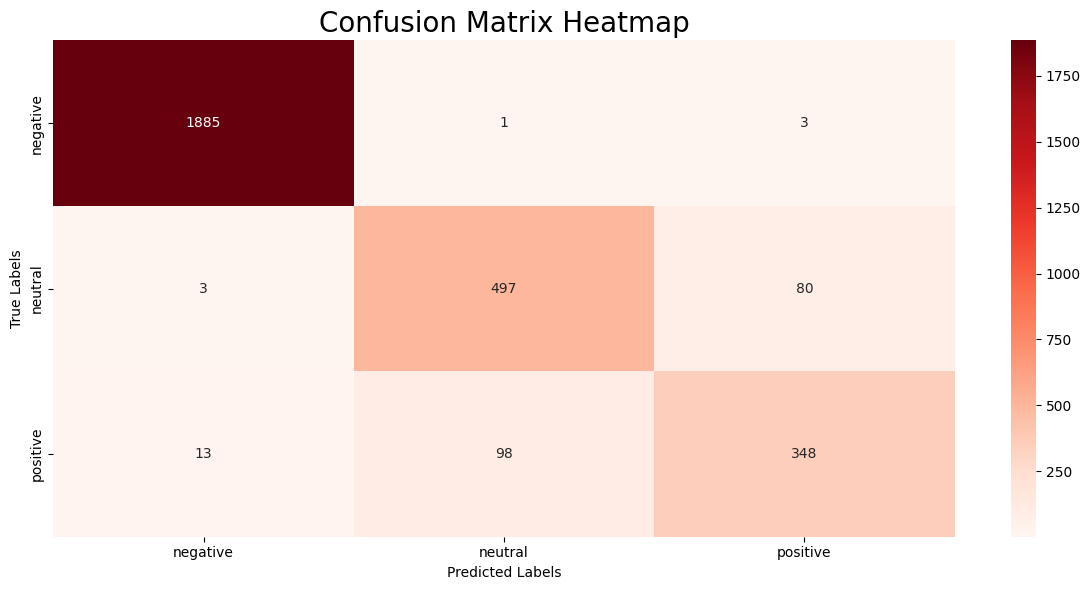

In [38]:
cm = confusion_matrix(y_test, prediction)

plt.figure(figsize=(12, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=le.classes_, 
            yticklabels=le.classes_)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap', fontsize=20)
plt.tight_layout()
plt.show()

### **Observation**

#### High Diagonal Dominance (Excellent Performance)
* **The Bird Eye View :** The heavy concentration of dark red and orange blocks along the main diagonal (top-left to bottom-right) indicating that the model is performing exceptionally well. 
* **Accuracy :** Summing up the diagonal yields **2,730 correct predictions** out of **2,928 total test samples**. This translates to exactly **93.24% accuracy**, perfectly matching the performance scores evaluated previously!

#### Breakdown by Individual Classes

* **Negative Class (Near-Perfection) :**
  * Out of 1,889 actual negative samples, the model correctly flags **1,885** of them.
  * It only makes 4 mistakes here (1 predicted as neutral, 3 as positive), achieving a near-flawless recall of **99.8%** for this class.

* **Neutral Class (Strong Performance) :**
  * Out of 580 actual neutral samples, **497** are correctly identified.
  * The main source of error here is predicting neutral text as **positive (80 instances)**. It almost never mistakes a neutral sample for a negative one (only 3 instances).

* **Positive Class (Good, with minor overlap) :**
  * Out of 459 actual positive samples, **348** are correctly identified.
  * The model's primary struggle here is distinguishing between positive and **neutral (98 instances)**.

#### Key Linguistic Insight: Adjacent Class Confusion
* A massive positive indicator for this model is that it rarely confuses polar opposites. 
* It almost never confuses **Negative** with **Positive** (only 3 true negatives called positive; only 13 true positives called negative).
* Instead, almost all misclassifications occur between **adjacent sentiment classes** (Neutral $\leftrightarrow$ Positive). In NLP sentiment analysis, this is highly acceptable and expected, as the boundary between a "neutral" statement and a "mildly positive" statement is naturally blurry even for humans.


The model has successfully resolved its prior class imbalance issues. It handles the majority class (negative) without drowning out or ignoring the minority classes (neutral and positive), proving that the text cleaning pipeline and training adjustments worked beautifully.

## Saving the model

In [ ]:
import pickle

# storing all the required objects into one object
model_assets = {
    'vectorizer' : tfidf,
    'processor' : processor,
    'model' : final_model
}

with open("sentiment_analysis_model.pkl", "wb") as f:
    pickle.dump(model_assets, f)

In [43]:
from IPython.display import FileLink
FileLink('sentiment_analysis_model.pkl')

/kaggle/working/sentiment_analysis_model.pkl